# 第11章：股票日频收益率分析

**学习目标**：读懂一行“股票—日期”数据；区分价格、涨跌幅和含红利收益率；用 pandas 制作累计收益率、波动率、回撤和成交指标；通过描述性统计认识 A 股样本。

配套课件：`../latex/chapter11.pdf`。数据来自本章提供的 CSMAR 授权 ZIP，限已有授权范围内使用。本 Notebook 保留执行结果，原始包和整理后的逐笔股票日数据仅保存在本地。

**教学顺序**：市场与数据 → 筛选与检查 → 单只股票 → 横截面统计 → 图表解释。

本章只做历史描述，不把样本统计解释为未来收益预测。

## 1. 中国 A 股市场与本章样本

A 股是人民币普通股票。交易所与板块不是同一层级：上交所有主板、科创板；深交所有主板、创业板；北交所主要服务创新型中小企业。深市主板与中小板已于 **2021-04-06** 合并。

本包 `Markettype` 的映射来自包内字段说明，**不按代码前缀猜板块**：1=沪市主板 A 股，4=深市主板 A 股，16=创业板，32=科创板，64=北交所；2、8 为 B 股。代码始终作为六位字符串保存。一个代码不一定等于一家公司跨期唯一身份；本包未提供证券简称、行业、上市退市日期和代码变更对应表。

参考（核对日期 2026-09-09）：[上交所股票分类](https://star.sse.com.cn/assortment/stock/list/share/)、[深市两板合并](https://www.szse.cn/aboutus/trends/news/t20210406_585442.html)、[北交所简介](https://www.bse.cn/company/introduce.html)。样本公司的多少由本包和筛选口径决定，不是交易所官方上市公司总数。

## 2. 从原始压缩包开始

选择课程根目录 `.venv` 内核，使用已有的 pandas、numpy、matplotlib 与 Jupyter 环境。解压使用 Python 标准库 `zipfile`，Windows 与 macOS 使用同一套代码。

将原始 ZIP 放在本章 `data/` 中，然后从头运行：查看包内目录 → 解压 → 试读 CSV 与字段说明 → 分块读取并选取教学年份 → 合并和检查。本 Notebook 不依赖预处理脚本、HDF5 或预先生成的数据概况。默认支持从 Notebook、本章或课程根目录启动。

In [1]:
from pathlib import Path
import json
import zipfile
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

cwd = Path.cwd()
if cwd.name == "notebooks":
    CHAPTER = cwd.parent
elif (cwd / "data").is_dir():
    CHAPTER = cwd
else:
    CHAPTER = cwd / "Chapter11 - 股票日频收益率分析"

DATA = CHAPTER / "data"
RAW_DIR = DATA / "raw"
TABLES = CHAPTER / "outputs/tables"
FIGURES = CHAPTER / "latex/figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)
YEAR = 2025
TARGET_CODE = "000001"
COMPARE_CODES = ["000001", "600000", "600519"]
ANNUAL_DAYS = 252  # 年化约定，不是声称每年恰有252个交易日
MIN_OBS = 200      # 跨股票比较时的最低有效观测数
BOARD = {1: "沪市主板", 4: "深市主板", 16: "创业板", 32: "科创板", 64: "北交所"}
ORDER = list(BOARD.values())
BLUE, GOLD, GRAY = "#003D73", "#CD9B37", "#696969"
plt.rcParams.update({"font.sans-serif": ["Microsoft YaHei", "PingFang SC", "DejaVu Sans"],
                     "axes.unicode_minus": False, "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 14, "axes.labelsize": 11})
print("Python:", sys.executable)
print("pandas:", pd.__version__, "| numpy:", np.__version__)
print("教学年度:", YEAR, "| 示例证券代码:", TARGET_CODE)

Python: D:\F Python data analysis\Lecture materials\.venv\Scripts\python.exe
pandas: 2.3.3 | numpy: 2.4.6
教学年度: 2025 | 示例证券代码: 000001


### 2.1 查看压缩包里有什么

先查看文件清单和解压后的大小。一个数据表被拆成多个 CSV，并不意味着每个 CSV 对应一个年份。字段说明和版权说明也是原始资料的一部分。

In [2]:
zip_paths = sorted(DATA.glob("*.zip"))
assert len(zip_paths) == 1, "请在 data 中放置本章唯一的原始 ZIP"
zip_path = zip_paths[0]
with zipfile.ZipFile(zip_path) as archive:
    members = archive.infolist()
    inventory = pd.DataFrame({"文件": [m.filename for m in members],
                              "解压后MiB": [m.file_size / 1024**2 for m in members]})
display(inventory.round(2))
print("原始压缩包：", zip_path.name)
print(f"解压后总大小：{inventory['解压后MiB'].sum():.1f} MiB")

,文件,解压后MiB
0,版权声明.pdf,0.22
1,TRDNEW_Dalyr[DES][csv].txt,0.00
2,TRDNEW_Dalyr.csv,241.95
3,TRDNEW_Dalyr1.csv,241.38
4,TRDNEW_Dalyr2.csv,250.58
5,TRDNEW_Dalyr3.csv,247.87
6,TRDNEW_Dalyr4.csv,242.62
7,TRDNEW_Dalyr5.csv,244.35
8,TRDNEW_Dalyr6.csv,218.99


原始压缩包： 日个股回报率文件163137917(仅供上海大学使用).zip
解压后总大小：1688.0 MiB


### 2.2 解压到本章 data/raw

`ZipFile` 打开 ZIP，`extract` 解压其中一个文件；循环遍历包内文件即可完成解压。已有文件保留，重复运行时只解压缺少的文件，便于保留手工编辑。需要还原已编辑的原始副本时，应先自行核对该文件。

下面确认解压目标位于 `data/raw` 内，再执行解压。原始 ZIP 保持不变。

In [3]:
RAW_DIR.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(zip_path) as archive:
    for member in archive.infolist():
        target = (RAW_DIR / member.filename).resolve()
        assert target.is_relative_to(RAW_DIR.resolve())
        if not target.exists():
            archive.extract(member, RAW_DIR)
            print("已解压：", member.filename)
        else:
            print("保留已有文件：", member.filename)
csv_paths = sorted(RAW_DIR.glob("TRDNEW_Dalyr*.csv"))
assert len(csv_paths) == sum(m.filename.endswith(".csv") for m in members)
print("CSV 文件数：", len(csv_paths))

已解压： 版权声明.pdf
已解压： TRDNEW_Dalyr[DES][csv].txt


已解压： TRDNEW_Dalyr.csv


已解压： TRDNEW_Dalyr1.csv


已解压： TRDNEW_Dalyr2.csv


已解压： TRDNEW_Dalyr3.csv


已解压： TRDNEW_Dalyr4.csv


已解压： TRDNEW_Dalyr5.csv


已解压： TRDNEW_Dalyr6.csv
CSV 文件数： 7


### 2.3 试读一个 CSV，理解数据类型

先用 `nrows=5` 试读，核对列名与取值，再读完整数据。`dtype={"Stkcd": "string"}` 保留股票代码开头的零；`parse_dates` 把日期文本转为可按年筛选的日期类型。收益率 `0.01` 表示 1%，市值字段 `Dsmvosd` 的单位是千元。

字段说明直接来自刚解压的 TXT；先显示前面部分，完整内容可在 VS Code 打开查看。

In [4]:
description_path = next(RAW_DIR.glob("*.txt"))
print(description_path.read_text(encoding="utf-8-sig")[:2400])
preview = pd.read_csv(csv_paths[0], nrows=5, encoding="utf-8-sig",
                      dtype={"Stkcd": "string"}, parse_dates=["Trddt", "Capchgdt"])
display(preview)
display(preview.dtypes.to_frame("数据类型"))

Stkcd [证券代码] - 以沪深京交易所公布的证券代码为准。
Trddt [交易日期] - 以YYYY-MM-DD表示。
Markettype [市场类型] - 1=上证A股市场 (不包含科创板），2=上证B股市场，4=深证A股市场（不包含创业板），8=深证B股市场，16=创业板， 32=科创板，64=北证A股市场。
Trdsta [交易状态] - 1=正常交易，2=ST，3＝*ST，4＝S（2006年10月9日及之后股改未完成），5＝SST，6＝S*ST，7=G（2006年10月9日之前已完成股改），8=GST，9=G*ST，10=U（2006年10月9日之前股改未完成），11=UST，12=U*ST，13=N，14=NST，15=N*ST，16=PT
Filling [填充标识] - 0=不填充，正常交易数据。1=非节假日填充，2=节假日填充。
Opnprc [日开盘价] - A股以人民币元计，上海B以美元计，深圳B以港币计
Hiprc [日最高价] - A股以人民币元计，上海B以美元计，深圳B以港币计
Loprc [日最低价] - A股以人民币元计，上海B以美元计，深圳B以港币计
Clsprc [日收盘价] - A股以人民币元计，上海B以美元计，深圳B以港币计
Dnshrtrd [日个股交易股数] - 0=没有交易量
Dnvaltrd [日个股交易金额] - A股以人民币元计，上海B以美元计，深圳B以港币计，0=没有交易量
Dsmvosd [日个股流通市值] - 计算公式为：个股的流通股数与收盘价的乘积，A股以人民币元计，上海B股以美元计，深圳B股以港币计，注意单位是千。（注：ABH同股，只计算A股总市值）
Dsmvtll [日个股总市值1] - 旧版计算方法。计算公式为：个股的总股数与收盘价的乘积，A股以人民币元计，上海B股以美元计，深圳B股以港币计，按当日汇率转换。（注：ABH同股，只计算A股总市值）
 A股：该字段计算用到的总股数计算公式为：个股的总股数= Nshrttl（总股数）-Nshrb (B股流通股数)-Nshrh(H股流通股数)-Nshroft(其它境外流通股)； B股：总股数Nshrttl=Nshrb B股流通股数；
Dsmvtl2 [日个股总市值2] - 计算公式为：个股的总股数与收盘价的乘积，A股以人民币元计，上海B股以美元计，深圳B

,Stkcd,Trddt,Markettype,Trdsta,Filling,Opnprc,Hiprc,Loprc,Clsprc,Dnshrtrd,...,Adjprcwd,Adjprcnd,Capchgdt,Ahshrtrd_D,Ahvaltrd_D,PreClosePrice,ChangeRatio,LimitDown,LimitUp,LimitStatus
0,000001,2021-08-16,4,1,0,20.09,20.20,19.57,19.95,62705022,...,3015.635523,2313.479895,2020-12-31,NaN,NaN,19.89,0.003017,17.90,21.88,0
1,000001,2021-08-17,4,1,0,19.85,20.22,19.61,19.67,47602194,...,2973.311078,2281.010205,2020-12-31,NaN,NaN,19.95,-0.014035,17.96,21.95,0
2,000001,2021-08-18,4,1,0,19.67,21.20,19.55,20.62,133273216,...,3116.913083,2391.176155,2020-12-31,NaN,NaN,19.67,0.048297,17.70,21.64,0
3,000001,2021-08-19,4,1,0,20.48,20.62,20.02,20.34,64997561,...,3074.588521,2358.706374,2020-12-31,NaN,NaN,20.62,-0.013579,18.56,22.68,0
4,000001,2021-08-20,4,1,0,19.97,20.07,18.70,19.42,161462793,...,2935.521807,2252.019726,2020-12-31,NaN,NaN,20.34,-0.045231,18.31,22.37,0


,数据类型
Stkcd,string[python]
Trddt,datetime64[ns]
Markettype,int64
Trdsta,int64
Filling,int64
Opnprc,float64
Hiprc,float64
Loprc,float64
Clsprc,float64
Dnshrtrd,int64


### 2.4 读取全部 CSV，同时选取教学年份

近689万行不必同时留在内存中。`chunksize=150_000` 让 `read_csv` 每次读取15万行，`for` 逐块处理；先按日期选出 `YEAR`，再把这一年的记录放入列表。这里仅选择年份，A股、填充记录等筛选留到第3节。

同时累计每个原文件的行数、全包年度分布、代码集合和日期范围。这些概况来自本次 CSV 读取，不读取现成的 JSON。首次运行需要解压空间；每次从头运行都会重新扫描所有 CSV，速度会比读取缓存慢。

In [5]:
year_parts = []
file_counts = []
year_counts = pd.Series(dtype="int64")
source_codes = set()
date_ranges = []
for csv_path in csv_paths:
    file_rows = 0
    reader = pd.read_csv(csv_path, encoding="utf-8-sig",
                         dtype={"Stkcd": "string"},
                         parse_dates=["Trddt", "Capchgdt"], chunksize=150_000)
    for chunk in reader:
        assert chunk.columns.tolist() == preview.columns.tolist()
        assert chunk["Stkcd"].str.fullmatch(r"\d{6}").all()
        assert chunk["Trddt"].notna().all()
        file_rows += len(chunk)
        years = chunk["Trddt"].dt.year
        year_counts = year_counts.add(years.value_counts(), fill_value=0)
        source_codes.update(chunk["Stkcd"].unique())
        date_ranges.append((chunk["Trddt"].min(), chunk["Trddt"].max()))
        year_parts.append(chunk.loc[years.eq(YEAR)].copy())
    file_counts.append({"CSV": csv_path.name, "行数": file_rows})
    print(f"已读取 {csv_path.name}：{file_rows:,} 行")
file_counts = pd.DataFrame(file_counts)
year_counts = year_counts.sort_index().astype("int64")
profile = {"rows": int(file_counts["行数"].sum()), "stock_codes": len(source_codes),
           "column_count": len(preview.columns),
           "date_min": str(min(a for a, b in date_ranges).date()),
           "date_max": str(max(b for a, b in date_ranges).date())}
assert profile["rows"] == year_counts.sum()
display(file_counts)
display(pd.Series(profile, name="原始包概况"))
display(year_counts.to_frame("原始记录数（含填充）"))

已读取 TRDNEW_Dalyr.csv：1,000,000 行


已读取 TRDNEW_Dalyr1.csv：1,000,000 行


已读取 TRDNEW_Dalyr2.csv：1,000,000 行


已读取 TRDNEW_Dalyr3.csv：1,000,000 行


已读取 TRDNEW_Dalyr4.csv：1,000,000 行


已读取 TRDNEW_Dalyr5.csv：1,000,000 行


已读取 TRDNEW_Dalyr6.csv：888,585 行


,CSV,行数
0,TRDNEW_Dalyr.csv,1000000
1,TRDNEW_Dalyr1.csv,1000000
2,TRDNEW_Dalyr2.csv,1000000
3,TRDNEW_Dalyr3.csv,1000000
4,TRDNEW_Dalyr4.csv,1000000
5,TRDNEW_Dalyr5.csv,1000000
6,TRDNEW_Dalyr6.csv,888585


rows               6888585
stock_codes           5830
column_count            27
date_min        2021-08-16
date_max        2026-08-13
Name: 原始包概况, dtype: object

,原始记录数（含填充）
Trddt,
2021,467867
2022,1283782
2023,1376436
2024,1425815
2025,1435881
2026,898804


### 2.5 合并年度记录并做基础检查

`pd.concat` 按行拼接各块，`ignore_index=True` 重新编号。`raw` 是后续分析起点，保留所选年份的全部27个字段及原始记录，不去重、不填零、不缩尾。拼接后释放临时列表。

核对年度行数与读取时的计数是否一致，再检查所选年份的主键与价格关系。全包覆盖统计与所选年份质量检查是两个范围；这些检查不代表全市场证券覆盖已完整。

In [6]:
raw = pd.concat(year_parts, ignore_index=True)
del year_parts, chunk, reader
assert len(raw) == year_counts.loc[YEAR]
assert raw["Trddt"].dt.year.eq(YEAR).all()
actual = raw.loc[raw["Filling"].eq(0)]
checks = pd.Series({
    "代码日期重复行": int(raw.duplicated(["Stkcd", "Trddt"]).sum()),
    "非填充记录非正收盘价": int(actual["Clsprc"].le(0).sum()),
    "非填充记录负成交量": int(actual["Dnshrtrd"].lt(0).sum()),
    "非填充记录高低价倒置": int(actual["Hiprc"].lt(actual["Loprc"]).sum()),
    "非填充记录收益率不大于-100%": int(actual["Dretwd"].le(-1).sum())})
display(checks.to_frame(f"{YEAR}年检查"))
assert checks.eq(0).all()
del actual
preview_columns = ["Stkcd", "Trddt", "Markettype", "Filling", "Clsprc", "Dretwd", "Dnvaltrd", "Dsmvosd"]
display(raw[preview_columns].head())
print(f"{YEAR} 年原始行数：{len(raw):,}；内存约 {raw.memory_usage(deep=True).sum()/1024**2:.1f} MiB")

,2025年检查
代码日期重复行,0
非填充记录非正收盘价,0
非填充记录负成交量,0
非填充记录高低价倒置,0
非填充记录收益率不大于-100%,0


,Stkcd,Trddt,Markettype,Filling,Clsprc,Dretwd,Dnvaltrd,Dsmvosd
0,000001,2025-01-01,4,2,11.70,0.000000,0.000000e+00,2.270452e+08
1,000001,2025-01-02,4,0,11.43,-0.023077,2.102923e+09,2.218057e+08
2,000001,2025-01-03,4,0,11.38,-0.004374,1.320521e+09,2.208354e+08
3,000001,2025-01-06,4,0,11.44,0.005272,1.234306e+09,2.219997e+08
4,000001,2025-01-07,4,0,11.51,0.006119,8.583290e+08,2.233581e+08


2025 年原始行数：1,435,881；内存约 371.1 MiB


### 2.6 字段不是越多越好：先理解口径

| 字段 | 含义 | 本章用法 |
|---|---|---|
| `Filling` | 0 原始交易记录；1 非节假日填充；2 节假日填充 | 分析只取 0 |
| `Trdsta` | 1 正常状态，2 ST，3 *ST 等 | 主样本保留，另做敏感性比较 |
| `Clsprc` | 未复权收盘价，A 股人民币元 | 认识价格水平 |
| `PreClosePrice`, `ChangeRatio` | 交易所昨收（可能已除权）及对应涨跌幅 | 验证 `Clsprc / PreClosePrice - 1` |
| `Dretwd`, `Dretnd` | 考虑现金红利再投资 / 不考虑现金红利的日回报率 | 主口径用 `Dretwd` |
| `Adjprcwd` | 与含红利口径对应的可比价格 | 检查相邻观测收益率 |
| `Dnshrtrd`, `Dnvaltrd` | 成交股数、成交金额（A 股元） | 量与额 |
| `Dsmvosd` | 流通市值（千元） | 估算流通股数与换手率 |
| `LimitStatus` | 1 涨停、-1 跌停、0 未涨跌停，可能缺失 | 不用统一10%阈值猜涨跌停 |

字段说明原文：`../data/raw/TRDNEW_Dalyr[DES][csv].txt`。数据包的“上市首日回报率”可能基于发行价；大收益率未必是数据错误。

In [7]:
display(raw["Filling"].value_counts().sort_index().rename(index={0: "0 原始记录", 1: "1 非节假日填充", 2: "2 节假日填充"}).to_frame("行数"))
missing_rate = raw.isna().mean().sort_values(ascending=False)
display(missing_rate[missing_rate > 0].to_frame("缺失比例"))

,行数
Filling,
0 原始记录,1333471
1 非节假日填充,3525
2 节假日填充,98885


,缺失比例
Ahvaltrd_D,0.659948
Ahshrtrd_D,0.659948
LimitStatus,0.071659
ChangeRatio,0.071322
LimitDown,0.000336
LimitUp,0.000318
Adjprcwd,0.000159
Adjprcnd,0.000159


## 3. 构造本章分析样本

按顺序筛选：A 股市场类型 → 非填充记录 → 有成交股数且收盘价为正 → 含红利收益率有限且大于 -100%。**不统一删除 ST，不按涨跌幅阈值删除极值，不把缺失收益率填成 0**。

此口径描述的是“可用、有成交的 A 股股票日”，不等于连续持有的可交易策略，也不保证含全部历史退市公司。

In [8]:
stages = [("年度原始记录", len(raw))]
selected = raw.loc[raw["Markettype"].isin(BOARD)].copy()
stages.append(("A股", len(selected)))
selected = selected.loc[selected["Filling"].eq(0)].copy()
stages.append(("非填充", len(selected)))
selected = selected.loc[selected["Dnshrtrd"].gt(0) & selected["Clsprc"].gt(0)].copy()
stages.append(("有成交且价格为正", len(selected)))
df = selected.loc[np.isfinite(selected["Dretwd"]) & selected["Dretwd"].gt(-1)].copy()
stages.append(("可计算收益率", len(df)))
df = df.sort_values(["Stkcd", "Trddt"]).reset_index(drop=True)
df["board"] = df["Markettype"].map(BOARD)
df["return"] = df["Dretwd"]
flow = pd.DataFrame(stages, columns=["筛选步骤", "行数"])
flow["本步剔除"] = flow["行数"].shift().sub(flow["行数"]).fillna(0).astype(int)
display(flow)
print(f"分析样本：{df.Stkcd.nunique():,} 个代码，{df.Trddt.nunique()} 个日期；{df.Trddt.min().date()} 至 {df.Trddt.max().date()}")
assert df["board"].notna().all()

,筛选步骤,行数,本步剔除
0,年度原始记录,1435881,0
1,A股,1414730,21151
2,非填充,1313872,100858
3,有成交且价格为正,1313872,0
4,可计算收益率,1313872,0


分析样本：5,500 个代码，243 个日期；2025-01-02 至 2025-12-31


### 3.1 填充记录会怎样影响统计？

比较原始 A 股、去除填充后的有成交样本，以及仅保留 `Trdsta=1` 的子样本。这里是口径敏感性检查，不把“正常状态”当成唯一正确的研究样本。

In [9]:
groups = {"A股原始记录（含填充）": raw.loc[raw.Markettype.isin(BOARD), "Dretwd"],
          "本章有成交样本": df["return"],
          "其中Trdsta=1": df.loc[df.Trdsta.eq(1), "return"]}
sensitivity = pd.DataFrame({name: {"行数": len(r), "日均值(%)": r.mean()*100,
                                      "日标准差(%)": r.std()*100,
                                      "零收益占比(%)": r.eq(0).mean()*100}
                            for name, r in groups.items()}).T
display(sensitivity.round(4))

,行数,日均值(%),日标准差(%),零收益占比(%)
A股原始记录（含填充）,1414730.0,0.1563,4.0611,9.5567
本章有成交样本,1313872.0,0.1683,4.2138,2.6140
其中Trdsta=1,1271538.0,0.1698,4.2424,2.5336


### 3.2 样本股票构成：使用同一个日期

按分析年度最后一个样本交易日计数，分母是当日满足筛选条件的代码。不能用全年出现过的代码数冒充年末上市公司数。北交所等板块如发生代码变化，本包不足以完成跨代码实体衔接。

,代码数,占比(%)
board,,
沪市主板,1694,31.04
深市主板,1487,27.24
创业板,1391,25.49
科创板,599,10.97
北交所,287,5.26


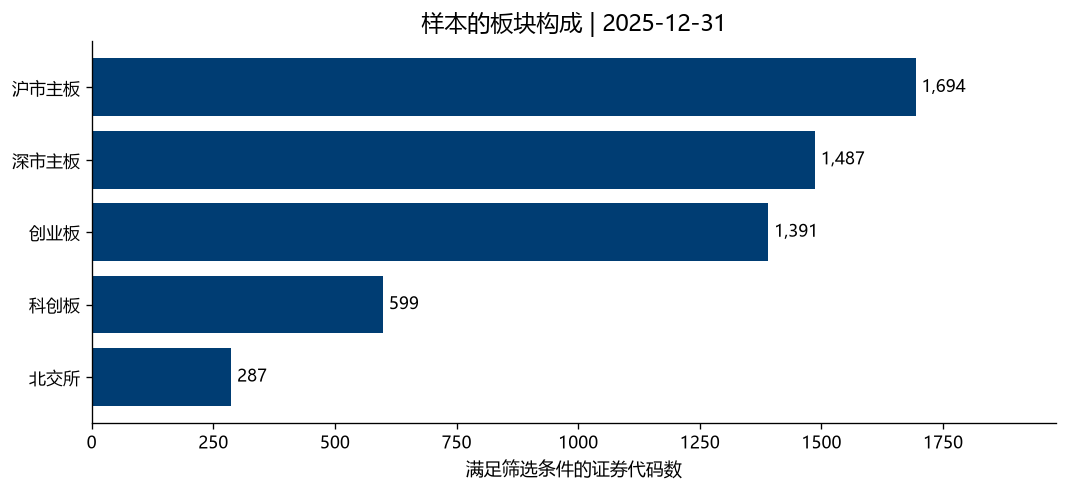

In [10]:
asof = df["Trddt"].max()
snapshot = df.loc[df.Trddt.eq(asof)]
board_counts = snapshot.groupby("board")["Stkcd"].nunique().reindex(ORDER, fill_value=0)
composition = board_counts.to_frame("代码数")
composition["占比(%)"] = board_counts / board_counts.sum() * 100
display(composition.round(2))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(ORDER, board_counts, color=BLUE)
for i, n in enumerate(board_counts): ax.text(n+12, i, f"{n:,}", va="center")
ax.set_xlim(0, board_counts.max()*1.17)
ax.invert_yaxis()
ax.set(xlabel="满足筛选条件的证券代码数", title=f"样本的板块构成 | {asof.date()}")
fig.tight_layout()
fig.savefig(FIGURES / "board_composition.png", dpi=180)
plt.show()

## 4. 从价格到收益率：先看一只股票

未复权价格变动：$r_t^{price}=P_t/P_{t-1}-1$。发生分红、送转、拆并股等事件时，不能简单用未复权价格变动表示投资回报。

主口径使用数据库的含红利回报率 `Dretwd`；`ChangeRatio` 是交易所涨跌幅，`Dretnd` 不考虑现金红利，三者不能混用。这里我们将会看到用未复权价格计算的收益率并不等于`Dretwd`。

选择代码 `000001` 仅为了演示，不代表投资推荐。先按股票、日期排序，再对单只股票做 `pct_change`；第一行没有上期样本价格，保留缺失。

In [ ]:
stock = df.loc[df.Stkcd.eq(TARGET_CODE)].copy().set_index("Trddt")
assert len(stock) > 60
stock["price_return"] = stock["Clsprc"].pct_change(fill_method=None)
stock["adjusted_return"] = stock["Adjprcwd"].pct_change(fill_method=None)
stock["exchange_return"] = stock["Clsprc"] / stock["PreClosePrice"] - 1
gap = (stock["price_return"] - stock["return"]).abs()   # 这里的return是Dretwd
comparison = stock[["Clsprc", "price_return", "Dretnd", "return", "adjusted_return", "ChangeRatio"]]
display(comparison.loc[gap.nlargest(5).index].sort_index().round(6))
print("交易所涨跌幅公式最大误差：", (stock.exchange_return-stock.ChangeRatio).abs().max())
print("可比价格相邻回报与Dretwd最大误差：", (stock.adjusted_return-stock["return"]).abs().max())
assert (stock.exchange_return-stock.ChangeRatio).abs().max() < 2e-6
assert (stock.adjusted_return-stock["return"]).abs().max() < 2e-6

,Clsprc,price_return,Dretnd,return,adjusted_return,ChangeRatio
Trddt,,,,,,
2025-06-12,11.68,-0.014346,-0.014346,0.016203,0.016203,0.016536
2025-09-09,11.75,0.004274,0.004274,0.004274,0.004274,0.004274
2025-10-15,11.40,-0.014693,-0.014693,0.005704,0.005704,0.006178
2025-11-14,11.75,0.004274,0.004274,0.004274,0.004274,0.004274
2025-12-09,11.43,-0.007812,-0.007813,-0.007813,-0.007813,-0.007813


交易所涨跌幅公式最大误差： 5.000000000005e-07
可比价格相邻回报与Dretwd最大误差： 5.043322738595979e-10


### 4.1 累计收益、对数收益与净值

$W_t=\prod_{s=1}^{t}(1+r_s)$，累计收益为 $W_t-1$；对数收益 $g_t=\ln(1+r_t)$ 满足 $\exp(\sum g_t)-1=\prod(1+r_t)-1$。

`W=1` 表示样本第一笔收益发生前的投入。第一笔数据库收益可能对应样本开始前的价格，不能再把样本第一天净值强行归一后称为同一个累计收益口径。

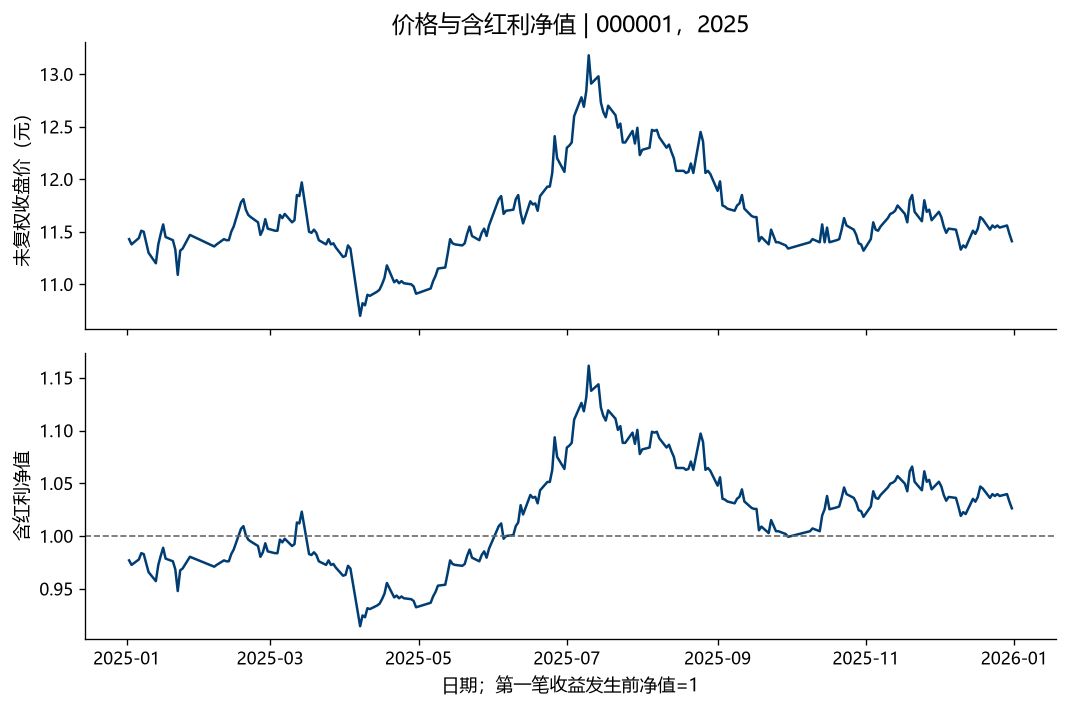

累计收益率：2.63%；直接相加：3.83%


In [12]:
stock["log_return"] = np.log1p(stock["return"])
stock["wealth"] = (1 + stock["return"]).cumprod()
stock["drawdown"] = stock["wealth"] / stock["wealth"].cummax().clip(lower=1) - 1
cumulative_return = stock["wealth"].iloc[-1] - 1
assert np.isclose(cumulative_return, np.expm1(stock.log_return.sum()))
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(stock.index, stock.Clsprc, color=BLUE)
axes[0].set(title=f"价格与含红利净值 | {TARGET_CODE}，{YEAR}", ylabel="未复权收盘价（元）")
axes[1].plot(stock.index, stock.wealth, color=BLUE)
axes[1].axhline(1, color=GRAY, ls="--", lw=1)
axes[1].set(ylabel="含红利净值", xlabel="日期；第一笔收益发生前净值=1")
fig.tight_layout()
fig.savefig(FIGURES / "price_wealth.png", dpi=180)
plt.show()
print(f"累计收益率：{cumulative_return:.2%}；直接相加：{stock['return'].sum():.2%}")

### 4.2 波动率与回撤回答不同问题

样本日波动率 $s=\sqrt{\frac{1}{n-1}\sum(r_t-\bar r)^2}$；近似年化波动率为 $s\sqrt{252}$。这里采用 252 个交易日的教学约定，依赖可比日频波动与平方根缩放假设。

回撤 $DD_t=W_t/\max(1,W_1,\ldots,W_t)-1$；最大回撤为 $\min DD_t$（本章报告负值）。20 日滚动波动率需要 20 条有效交易观测，不是 20 个自然日。删除无成交日意味着指标按可用观测计算，停牌或数据间断仍需解释。

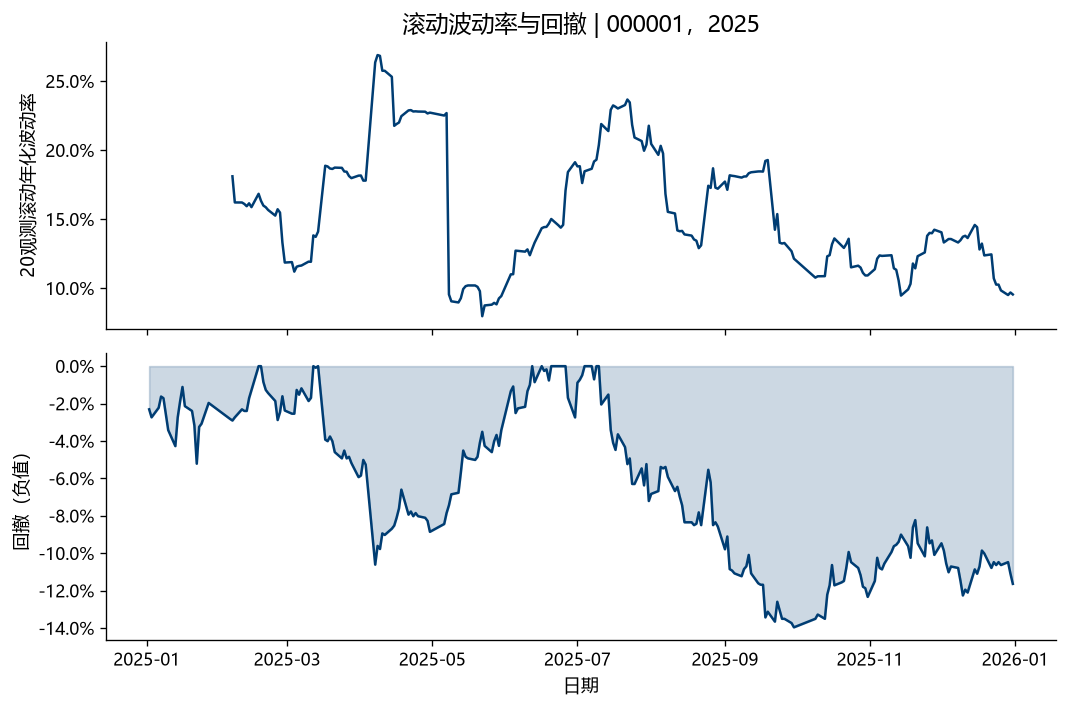

有效观测数       243.000000
累计收益率         0.026252
日均收益率         0.000158
日标准差          0.010085
近似年化波动率       0.160096
最大回撤（负值）     -0.139607
Name: 000001, dtype: float64

In [13]:
stock["vol20"] = stock["return"].rolling(20, min_periods=20).std(ddof=1) * np.sqrt(ANNUAL_DAYS)
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(stock.index, stock.vol20, color=BLUE)
axes[0].set(title=f"滚动波动率与回撤 | {TARGET_CODE}，{YEAR}", ylabel="20观测滚动年化波动率")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].fill_between(stock.index, stock.drawdown, 0, color=BLUE, alpha=.2)
axes[1].plot(stock.index, stock.drawdown, color=BLUE)
axes[1].set(ylabel="回撤（负值）", xlabel="日期")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
fig.tight_layout()
fig.savefig(FIGURES / "vol_drawdown.png", dpi=180)
plt.show()
display(pd.Series({"有效观测数": len(stock), "累计收益率": cumulative_return,
                   "日均收益率": stock["return"].mean(),
                   "日标准差": stock["return"].std(),
                   "近似年化波动率": stock["return"].std()*np.sqrt(ANNUAL_DAYS),
                   "最大回撤（负值）": stock.drawdown.min()}, name=TARGET_CODE))

## 5. 基本交易指标：量、额、市值与换手率

成交金额（亿元）=`Dnvaltrd / 1e8`；流通市值（亿元）=`Dsmvosd * 1000 / 1e8`。

由流通市值反推流通股数：$S_t^{float}\approx MV_t^{float}/P_t$；估算日换手率 $Turnover_t=Volume_t/S_t^{float}$。这里是**根据本包流通市值口径估算**，不等同于供应商的自由流通换手率。分母非正时保留缺失，不造出 0。

In [14]:
df["amount_100m"] = df["Dnvaltrd"] / 1e8
df["float_mv_100m"] = df["Dsmvosd"] * 1000 / 1e8
float_shares = df["Dsmvosd"] * 1000 / df["Clsprc"]
df["turnover"] = df["Dnshrtrd"] / float_shares.where(float_shares.gt(0))
df["intraday_range"] = (df["Hiprc"] - df["Loprc"]) / df["PreClosePrice"].where(df.PreClosePrice.gt(0))
display(df[["amount_100m", "float_mv_100m", "turnover", "intraday_range"]].describe(percentiles=[.01,.5,.99]).round(4))
print("换手率缺失数：", df.turnover.isna().sum())

,amount_100m,float_mv_100m,turnover,intraday_range
count,1.313872e+06,1.313872e+06,1.313872e+06,1.313872e+06
mean,3.198200e+00,1.585629e+02,3.900000e-02,3.770000e-02
std,7.654400e+00,6.873347e+02,4.940000e-02,3.270000e-02
min,6.000000e-04,4.033000e-01,0.000000e+00,0.000000e+00
1%,1.279000e-01,6.890400e+00,2.400000e-03,8.000000e-03
50%,1.216300e+00,4.918130e+01,2.310000e-02,3.000000e-02
99%,3.204320e+01,1.798276e+03,2.492000e-01,1.441000e-01
max,4.504400e+02,2.742308e+04,9.828000e-01,1.377670e+01


换手率缺失数： 0


## 6. 描述性统计：先讲清“对谁求平均”

下面把每条股票日视为一个观测，计算**混合股票日分布**。上市较早、交易天数较多的股票会贡献更多观测；这不是等权组合的年收益率。

均值描述中心，中位数抗极值；标准差描述离散程度；1%/99% 分位数描述尾部；偏度描述不对称性；pandas 的 `kurt()` 是**超额峰度**（正态分布为 0）。

In [15]:
r = df["return"]
return_stats = pd.Series({"观测数": r.count(), "均值(%)": r.mean()*100,
    "中位数(%)": r.median()*100, "标准差(%)": r.std()*100,
    "最小值(%)": r.min()*100, "1%分位(%)": r.quantile(.01)*100,
    "99%分位(%)": r.quantile(.99)*100, "最大值(%)": r.max()*100,
    "偏度": r.skew(), "超额峰度": r.kurt(), "正收益占比(%)": r.gt(0).mean()*100})
display(return_stats.round(4).to_frame("混合股票日统计"))
extremes = pd.concat([df.nsmallest(5, "return"), df.nlargest(5, "return")])
display(extremes[["Stkcd", "Trddt", "board", "Trdsta", "return", "ChangeRatio", "LimitStatus"]])

,混合股票日统计
观测数,1.313872e+06
均值(%),1.683000e-01
中位数(%),0.000000e+00
标准差(%),4.213800e+00
最小值(%),-8.932580e+01
1%分位(%),-7.974100e+00
99%分位(%),1.000900e+01
最大值(%),1.211111e+03
偏度,6.047600e+01
超额峰度,1.053694e+04


,Stkcd,Trddt,board,Trdsta,return,ChangeRatio,LimitStatus
42624,000622,2025-06-25,深市主板,3,-0.893258,-0.893258,NaN
202973,002336,2025-06-13,深市主板,3,-0.850949,-0.850949,NaN
36727,000584,2025-06-20,深市主板,3,-0.849315,-0.849315,NaN
776890,600462,2025-06-24,沪市主板,3,-0.802083,-0.802083,NaN
423101,300280,2025-09-15,创业板,3,-0.770073,-0.770073,NaN
1256982,920091,2025-11-21,北交所,1,12.111111,12.111111,NaN
1253029,920045,2025-12-31,北交所,1,8.781576,8.781576,NaN
1257740,920100,2025-09-08,北交所,1,7.856172,7.856172,NaN
1247357,688802,2025-12-17,科创板,1,6.929486,6.929486,NaN
959313,603124,2025-03-20,沪市主板,1,6.068311,6.068311,NaN


### 两条极值的业务核验

已核对两条交易所披露：

- [北交所上市报道](https://www.bse.cn/issue_report_meeting/200027211.html)：920091 于 **2025-11-21** 上市，发行价 **9 元**；本包最大收益率正出现在该日。发行价到首日收盘的收益不能理解为普通投资者在首日开盘买入即可获得的收益。
- [000622 公司退市公告（深交所披露）](https://disc.static.szse.cn/disc/disk03/finalpage/2025-06-19/ac36f03f-1bba-480d-9012-df4c030c22cb.PDF)：**2025-06-25** 为退市整理期首日，当日不设价格涨跌幅限制；本包最小收益率出现在该日。

这验证了两条记录的事件背景，**并不代表全部极值已逐一核验**。下表另外核对本包价格和涨跌幅公式。

In [16]:
event_rows = df.loc[((df.Stkcd == "920091") & (df.Trddt == "2025-11-21")) |
                       ((df.Stkcd == "000622") & (df.Trddt == "2025-06-25")),
                       ["Stkcd", "Trddt", "Clsprc", "PreClosePrice", "return", "ChangeRatio"]].copy()
event_rows["价格核算收益"] = event_rows.Clsprc / event_rows.PreClosePrice - 1
display(event_rows)
assert len(event_rows) == 2
assert (event_rows["价格核算收益"] - event_rows.ChangeRatio).abs().max() < 2e-6
assert event_rows.loc[event_rows.Stkcd.eq("920091"), "PreClosePrice"].iloc[0] == 9.0

,Stkcd,Trddt,Clsprc,PreClosePrice,return,ChangeRatio,价格核算收益
42624,000622,2025-06-25,0.19,1.78,-0.893258,-0.893258,-0.893258
1256982,920091,2025-11-21,118.00,9.00,12.111111,12.111111,12.111111


### 6.1 画完整分布，也看主体区间

左图保留所有收益率，纵轴取对数便于看尾部；右图只显示 -10% 至 10% 的细节，并标注区间外数量。图形缩放不改变统计样本。极值需要查公司事件和上市资料，本章不在缺少证据时判为坏数据。

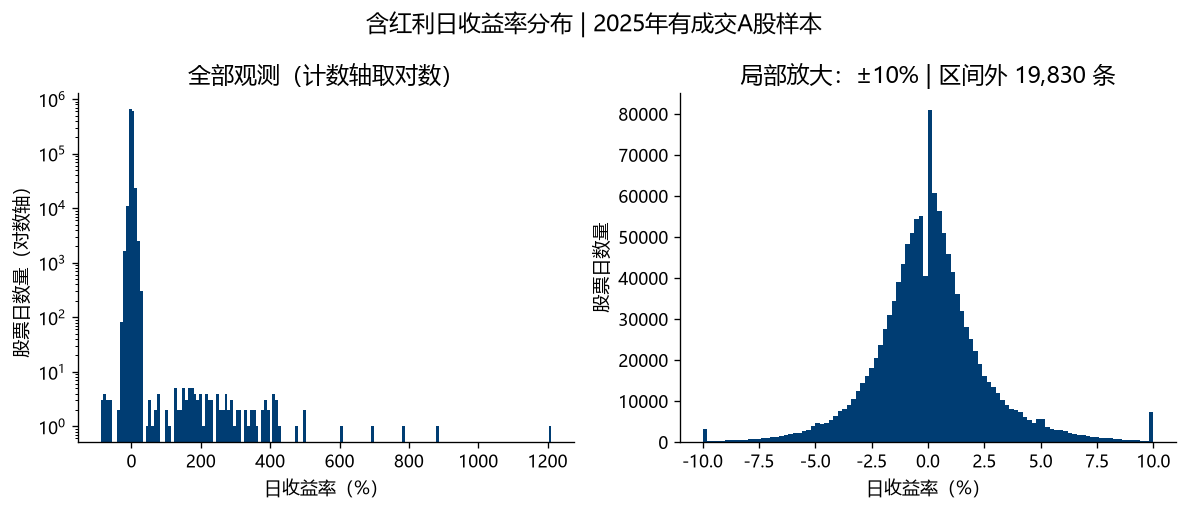

In [17]:
outside = int(r.abs().gt(.10).sum())
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
axes[0].hist(r*100, bins=160, color=BLUE, log=True)
axes[0].set(title="全部观测（计数轴取对数）", xlabel="日收益率（%）", ylabel="股票日数量（对数轴）")
axes[1].hist(r*100, bins=np.linspace(-10,10,101), color=BLUE)
axes[1].set(title=f"局部放大：±10% | 区间外 {outside:,} 条", xlabel="日收益率（%）", ylabel="股票日数量")
fig.suptitle(f"含红利日收益率分布 | {YEAR}年有成交A股样本", fontsize=14)
fig.tight_layout()
fig.savefig(FIGURES / "return_distribution.png", dpi=180)
plt.show()

### 6.2 按板块分组：相同指标，不同样本

板块内仍是股票日加权的混合分布。保留 ST 和极值；板块差异可能同时来自规模、行业、上市时间等因素，不能解释为板块导致收益差异。

,代码数,股票日数,日均收益,日中位数,日标准差,日收益1分位,日收益99分位
board,,,,,,,
沪市主板,1716,410676,0.00126,0.00000,0.03295,-0.07420,0.10000
深市主板,1497,360045,0.00138,0.00000,0.03116,-0.07856,0.10000
创业板,1399,334752,0.00184,0.00006,0.04202,-0.08142,0.11327
科创板,600,142635,0.00243,0.00018,0.04657,-0.08010,0.11177
北交所,288,65764,0.00356,0.00000,0.09839,-0.09797,0.15352


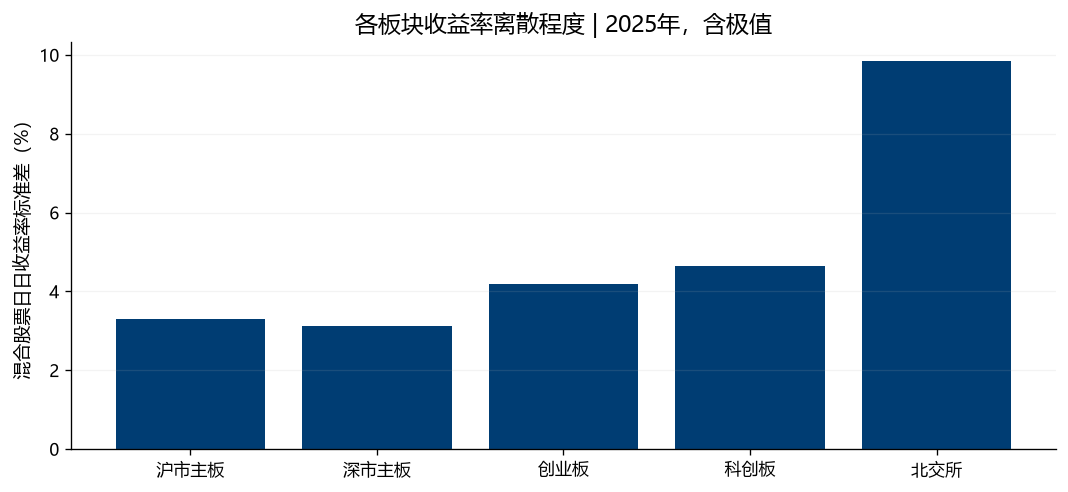

In [18]:
board_stats = df.groupby("board").agg(代码数=("Stkcd","nunique"), 股票日数=("return","size"),
    日均收益=("return","mean"), 日中位数=("return","median"), 日标准差=("return","std"),
    日收益1分位=("return",lambda x:x.quantile(.01)), 日收益99分位=("return",lambda x:x.quantile(.99)))
board_stats = board_stats.reindex(ORDER)
display(board_stats.round(5))
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(ORDER, board_stats["日标准差"]*100, color=BLUE)
ax.set(ylabel="混合股票日日收益率标准差（%）", title=f"各板块收益率离散程度 | {YEAR}年，含极值")
ax.grid(axis="y", alpha=.15)
fig.tight_layout()
fig.savefig(FIGURES / "board_dispersion.png", dpi=180)
plt.show()

## 7. 股票层面的汇总与共同日期比较

对每个代码分别统计有效样本数、区间累计收益率和年化波动率；风险收益图只显示至少 200 条观测的代码。这会排除部分新股或停牌较多的证券，不能保证所有代码覆盖完全相同的持有区间。

,n,first_date,last_date,cumulative_return,annual_vol
Stkcd,,,,,
000001,243,2025-01-02,2025-12-31,0.026252,0.160096
600000,243,2025-01-02,2025-12-31,0.245703,0.249284
600519,243,2025-01-02,2025-12-31,-0.063082,0.170176


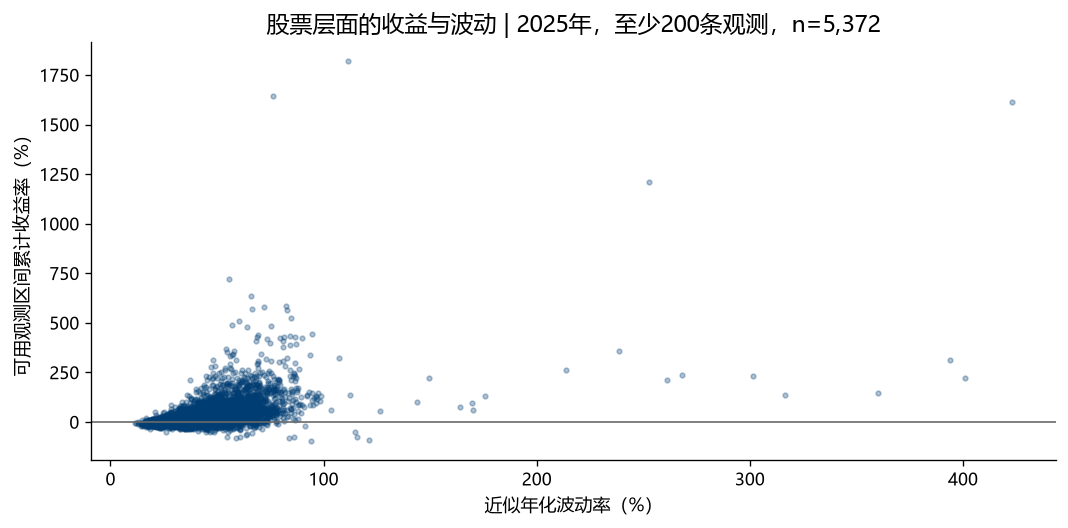

In [19]:
df["log_return"] = np.log1p(df["return"])
stock_stats = df.groupby("Stkcd").agg(n=("return","size"), mean=("return","mean"),
    std=("return","std"), log_sum=("log_return","sum"), first_date=("Trddt","min"),
    last_date=("Trddt","max"), board=("board","last"))
stock_stats["cumulative_return"] = np.expm1(stock_stats["log_sum"])
stock_stats["annual_vol"] = stock_stats["std"] * np.sqrt(ANNUAL_DAYS)
eligible = stock_stats.loc[stock_stats.n.ge(MIN_OBS)]
display(stock_stats.loc[COMPARE_CODES, ["n", "first_date", "last_date", "cumulative_return", "annual_vol"]])
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(eligible.annual_vol*100, eligible.cumulative_return*100, s=8, alpha=.30, color=BLUE, rasterized=True)
ax.axhline(0, color=GRAY, lw=1)
ax.set(xlabel="近似年化波动率（%）", ylabel="可用观测区间累计收益率（%）",
       title=f"股票层面的收益与波动 | {YEAR}年，至少{MIN_OBS}条观测，n={len(eligible):,}")
fig.tight_layout()
fig.savefig(FIGURES / "risk_return.png", dpi=180)
plt.show()

共同有效日期：243；范围：2025-01-02 至 2025-12-31


Stkcd,000001,600000,600519
Stkcd,,,
000001,1.000,0.528,0.331
600000,0.528,1.000,0.266
600519,0.331,0.266,1.000


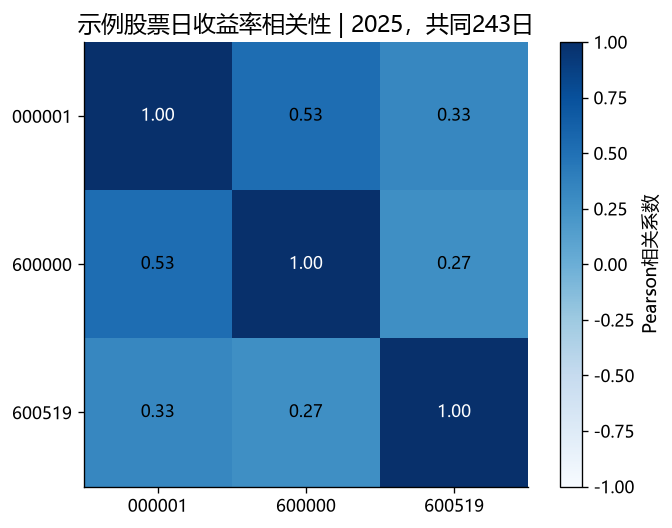

In [20]:
wide = df.loc[df.Stkcd.isin(COMPARE_CODES)].pivot(index="Trddt", columns="Stkcd", values="return")
common = wide.dropna()
print(f"共同有效日期：{len(common)}；范围：{common.index.min().date()} 至 {common.index.max().date()}")
display(common.corr().round(3))
fig, ax = plt.subplots(figsize=(6, 4.5))
im = ax.imshow(common.corr(), vmin=-1, vmax=1, cmap="Blues")
ax.set_xticks(range(len(COMPARE_CODES)), common.columns)
ax.set_yticks(range(len(COMPARE_CODES)), common.columns)
for i in range(len(COMPARE_CODES)):
    for j in range(len(COMPARE_CODES)):
        v = common.corr().iloc[i,j]
        ax.text(j,i,f"{v:.2f}",ha="center",va="center",color="white" if v>.65 else "black")
ax.set_title(f"示例股票日收益率相关性 | {YEAR}，共同{len(common)}日")
fig.colorbar(im, ax=ax, label="Pearson相关系数")
fig.tight_layout()
fig.savefig(FIGURES / "correlation.png", dpi=180)
plt.show()

## 8. 导出教学结果并核对

下面只导出汇总表、图表及课件用的统计宏；解压后的原始文件保存在被 Git 忽略的本地 `data/raw/`，年度数据在内存中计算。所有图题明确年度与口径，新增数据后应重新执行本 Notebook 并重新编译课件。

In [21]:
flow.to_csv(TABLES / "sample_flow.csv", index=False, encoding="utf-8-sig")
composition.to_csv(TABLES / "board_composition.csv", encoding="utf-8-sig")
return_stats.to_csv(TABLES / "return_statistics.csv", encoding="utf-8-sig")
board_stats.to_csv(TABLES / "board_statistics.csv", encoding="utf-8-sig")
sensitivity.to_csv(TABLES / "sample_sensitivity.csv", encoding="utf-8-sig")
common.corr().to_csv(TABLES / "example_correlations.csv", encoding="utf-8-sig")
summary = {"year": YEAR, "source_rows": profile["rows"], "source_codes": profile["stock_codes"],
    "source_start": profile["date_min"], "source_end": profile["date_max"],
    "raw_year_rows": len(raw), "analysis_rows": len(df), "analysis_codes": int(df.Stkcd.nunique()),
    "analysis_dates": int(df.Trddt.nunique()), "start": str(df.Trddt.min().date()), "end": str(asof.date()),
    "snapshot_codes": int(board_counts.sum()), "mean_pct": r.mean()*100, "median_pct": r.median()*100,
    "std_pct": r.std()*100, "min_pct": r.min()*100, "max_pct": r.max()*100,
    "q01_pct": r.quantile(.01)*100, "q99_pct": r.quantile(.99)*100,
    "skew": r.skew(), "excess_kurtosis": r.kurt(), "outside_10pct": outside,
    "target_code": TARGET_CODE, "target_n": len(stock), "target_cum_pct": cumulative_return*100,
    "target_vol_pct": stock["return"].std()*np.sqrt(ANNUAL_DAYS)*100,
    "target_mdd_pct": stock.drawdown.min()*100,
    "comparison_codes": len(eligible), "common_days": len(common),
    "max_adjusted_error": float((stock.adjusted_return-stock["return"]).abs().max())}
(CHAPTER / "outputs/analysis_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
macros = {"SampleYear": str(YEAR), "SourceRows": f"{profile['rows']:,}", "SourceCodes": str(profile["stock_codes"]),
    "SampleRows": f"{len(df):,}", "SampleCodes": f"{df.Stkcd.nunique():,}", "SampleDays": str(df.Trddt.nunique()),
    "SnapshotCodes": f"{board_counts.sum():,}", "SampleEnd": str(asof.date()),
    "ReturnMean": f"{r.mean()*100:.3f}", "ReturnMedian": f"{r.median()*100:.3f}",
    "ReturnStd": f"{r.std()*100:.3f}", "ReturnLow": f"{r.quantile(.01)*100:.3f}",
    "ReturnHigh": f"{r.quantile(.99)*100:.3f}", "ReturnMin": f"{r.min()*100:.2f}", "ReturnMax": f"{r.max()*100:.2f}",
    "ReturnSkew": f"{r.skew():.2f}", "ReturnKurt": f"{r.kurt():.2f}",
    "TargetCum": f"{cumulative_return*100:.2f}", "TargetVol": f"{stock['return'].std()*np.sqrt(ANNUAL_DAYS)*100:.2f}",
    "TargetMdd": f"{stock.drawdown.min()*100:.2f}", "TargetCount": str(len(stock))}
(CHAPTER / "latex/analysis_numbers.tex").write_text("% Generated by the executed Chapter 11 notebook.\n" +
    "\n".join("\\newcommand{\\"+k+"}{"+v+"}" for k,v in macros.items()), encoding="utf-8")
assert flow.iloc[-1]["行数"] == int(board_stats["股票日数"].sum()) == len(df)
assert np.isclose(composition["占比(%)"].sum(),100)
assert np.isclose(cumulative_return,(1+stock["return"]).prod()-1)
print("汇总表、7张图和课件统计宏已更新；样本计数、构成比例与累计收益核对通过。")

汇总表、7张图和课件统计宏已更新；样本计数、构成比例与累计收益核对通过。


## 9. 根据实际输出做解释

重新运行时，先读下面动态生成的结果，再回答：均值和中位数为什么不同？全样本极值与 ±10% 局部图分别告诉我们什么？价格曲线与含红利净值为什么不完全一致？

In [22]:
print(f"{YEAR} 年分析样本有 {df.Stkcd.nunique():,} 个代码、{len(df):,} 条股票日记录、{df.Trddt.nunique()} 个日期。")
print(f"股票日均值为 {r.mean():.3%}，中位数为 {r.median():.3%}，日标准差为 {r.std():.3%}。")
print(f"1%和99%分位为 {r.quantile(.01):.3%}、{r.quantile(.99):.3%}；极值保留在全样本统计中。")
print(f"代码{TARGET_CODE}在{len(stock)}条可用观测上的累计收益为{cumulative_return:.2%}，最大回撤为{stock.drawdown.min():.2%}。")

2025 年分析样本有 5,500 个代码、1,313,872 条股票日记录、243 个日期。
股票日均值为 0.168%，中位数为 0.000%，日标准差为 4.214%。
1%和99%分位为 -7.974%、10.009%；极值保留在全样本统计中。
代码000001在243条可用观测上的累计收益为2.63%，最大回撤为-13.96%。


### 解释边界与下一步

- 原包不是已核验的历史全市场证券名录；股票退市覆盖、代码变更和新股发行价需要额外资料。这里只验证了包内数据及本章口径。
- 未将日收益率混合均值当作指数收益率；未用当前市值加权收益率，避免把当日结果信息放入期初权重。
- 新股、除权除息、ST、停牌和不同板块的交易制度都会影响分布。遇到极值先核对业务事件，不机械截断到 ±10%。
- 相关系数基于共同日期的历史样本；不表示因果，也不保证未来相关性稳定。
- 日频数据不能观察盘中价格路径；日内高低价范围只是一个摘要。若研究日内交易，需要分钟或逐笔数据。
- 可继续修改年份、证券代码或最低观测数；比较完整原样本与去除新股等更严格样本，但每一次筛选都应说明分母和影响。